# Lecture 01 — Simple Linear Regression

**ISLP Reference:** Chapter 3.1 — Simple Linear Regression  
**Dataset:** Brasileirão Série A 2025 (Impect API)

## Theoretical Context

Simple linear regression models a single predictor $X$ to explain a quantitative response $Y$:

$$Y = \beta_0 + \beta_1 X + \varepsilon$$

### Inference — what the model tells us about the data
- **$\hat{\beta}_0$, $\hat{\beta}_1$**: OLS estimates (minimise RSS)
- **Standard Error (SE)**: uncertainty around each estimate
- **t-statistic / p-value**: tests $H_0: \beta_1 = 0$ (predictor carries no information)
- **95% CI for coefficient**: plausible range for the true $\beta_1$
- **RSE**: typical error of a single prediction (same unit as $Y$)
- **R²**: fraction of variance in $Y$ explained by the model

### Prediction — what the model tells us about new data
- **Point prediction** $\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1 x^*$: expected value for a new $x^*$
- **Confidence Interval (CI)**: interval for $E[Y | X = x^*]$ — uncertainty about the **mean line**
- **Prediction Interval (PI)**: interval for a **single new observation** — always wider than the CI

### Variable choice & leakage rationale
- **Target — `POSTSHOT_XG`**: post-shot expected goals; updated after the shot is taken, accounting for actual trajectory and placement. More predictive of goals than pre-shot xG.
- **Predictor — `SHOT_AT_GOAL_NUMBER_IN_PITCH_POSITION_OPPONENT_BOX`**: count of shots taken from inside the box. Chosen because (1) shot location is the strongest determinant of shot quality, (2) it is a pure count measured *before* shot quality is evaluated — no leakage from the post-shot model itself.

**Football application:** do teams that generate more shots from inside the box produce higher post-shot xG per match in Série A 2025?

---
## 1 · Imports

In [1]:
# ===================== IMPORTS =====================

# stdlib
import sys
import os

# third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# local
sys.path.append(os.path.join(os.getcwd(), '..'))
from utils.football_helpers import COLORS, SEQUENTIAL_PALETTE, apply_style

apply_style()

---
## 2 · Data Loading

In [2]:
# ===================== DATA LOADING =====================

DATA_PATH = "../data/squadMatchsums_brasileirao_2025.xlsx"

df_raw = pd.read_excel(DATA_PATH)

print(f"Shape: {df_raw.shape}")
df_raw.head(3)

Shape: (760, 1478)


,matchId,dateTime,competitionName,competitionId,competitionType,iterationId,season,matchDayIndex,matchDayName,squadId,...,NEUTRAL_PASSES_AT_PHASE_IN_POSSESSION,NEUTRAL_PASSES_AT_PHASE_ATTACKING_TRANSITION,NEUTRAL_PASSES_AT_PHASE_DEFENSIVE_TRANSITION,NEUTRAL_PASSES_AT_PHASE_OUT_OF_POSSESSION,NEUTRAL_PASSES_AT_PHASE_SET_PIECE,NEUTRAL_PASSES_AT_PHASE_SECOND_BALL,SHOT_ASSISTS,EXPECTED_SHOT_ASSISTS,EXPECTED_GOAL_ASSISTS,EXPECTED_PASSES
0,196541,2025-03-29T21:30:00Z,Campeonato Brasileiro Série A,13,League,1277,2025,0,1. Spieltag,467,...,27,8,0,0,7,2,11,8.914383,1.541134,490.14620
1,196541,2025-03-29T21:30:00Z,Campeonato Brasileiro Série A,13,League,1277,2025,0,1. Spieltag,470,...,12,9,0,0,12,4,3,3.296435,0.418939,269.19943
2,196542,2025-03-29T21:30:00Z,Campeonato Brasileiro Série A,13,League,1277,2025,0,1. Spieltag,461,...,19,12,0,0,12,5,8,7.764456,1.096777,317.20877


In [3]:
# Quick overview of columns
df_raw.dtypes.value_counts()

int64      763
float64    708
object       7
Name: count, dtype: int64

In [4]:
# Print all column names to help with selection
for i, col in enumerate(df_raw.columns):
    print(f"{i:4d}  {col}")

   0  matchId
   1  dateTime
   2  competitionName
   3  competitionId
   4  competitionType
   5  iterationId
   6  season
   7  matchDayIndex
   8  matchDayName
   9  squadId
  10  wyscoutId
  11  heimSpielId
  12  skillCornerId
  13  optaId
  14  statsPerformId
  15  transfermarktId
  16  soccerdonnaId
  17  squadName
  18  coachId
  19  coachName
  20  BYPASSED_OPPONENTS
  21  BYPASSED_OPPONENTS_NUMBER
  22  BYPASSED_DEFENDERS
  23  BYPASSED_OPPONENTS_WO_VERIFICATION
  24  BYPASSED_DEFENDERS_WO_VERIFICATION
  25  BYPASSED_OPPONENTS_BY_ACTION_SECOND_BALL
  26  BYPASSED_OPPONENTS_RECEIVING
  27  BYPASSED_OPPONENTS_RECEIVING_NUMBER
  28  BYPASSED_DEFENDERS_RECEIVING
  29  BYPASSED_OPPONENTS_RECEIVING_DUETO_VERIFICATION
  30  NEUTRAL_PLAY_NUMBER
  31  REVERSE_PLAY_ADDED_OPPONENTS
  32  REVERSE_PLAY_NUMBER
  33  PLAYDURATION
  34  MATCH_SHARE
  35  BALL_LOSS_ADDED_OPPONENTS
  36  BALL_LOSS_REMOVED_TEAMMATES
  37  BALL_LOSS_NUMBER
  38  BALL_WIN_ADDED_TEAMMATES
  39  BALL_WIN_REMOVED_OPP

---
## 3 · Preprocessing

In [5]:
# ===================== VARIABLE SELECTION =====================

TARGET    = "POSTSHOT_XG"
PREDICTOR = "SHOT_AT_GOAL_NUMBER_IN_PITCH_POSITION_OPPONENT_BOX"

df = df_raw[[TARGET, PREDICTOR]].dropna().copy()

print(f"Rows: {len(df)}")
df.describe()

Rows: 760


,POSTSHOT_XG,SHOT_AT_GOAL_NUMBER_IN_PITCH_POSITION_OPPONENT_BOX
count,760.000000,760.000000
mean,1.341584,7.472368
std,0.933406,3.739089
min,0.000000,0.000000
25%,0.644035,5.000000
50%,1.188195,7.000000
75%,1.860088,10.000000
max,5.328240,22.000000


---
## 4 · Modelling

### 4.1 · Model Fitting

In [6]:
# ===================== FIT OLS MODEL =====================

X = sm.add_constant(df[[PREDICTOR]])
y = df[TARGET]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            POSTSHOT_XG   R-squared:                       0.304
Model:                            OLS   Adj. R-squared:                  0.303
Method:                 Least Squares   F-statistic:                     331.6
Date:                Fri, 01 May 2026   Prob (F-statistic):           9.84e-62
Time:                        16:18:30   Log-Likelihood:                -887.63
No. Observations:                 760   AIC:                             1779.
Df Residuals:                     758   BIC:                             1789.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

### 4.2 · Inference

Extracting and interpreting each diagnostic metric produced by the model.

In [7]:
# ===================== INFERENCE =====================

b0, b1 = model.params["const"], model.params[PREDICTOR]
se_b1  = model.bse[PREDICTOR]
t_b1   = model.tvalues[PREDICTOR]
p_b1   = model.pvalues[PREDICTOR]
ci_b1  = model.conf_int().loc[PREDICTOR]
rse    = np.sqrt(model.mse_resid)
r2     = model.rsquared
f_stat = model.fvalue
f_p    = model.f_pvalue

print("=" * 52)
print("  COEFFICIENTS")
print("=" * 52)
print(f"  β̂₀  (intercept) = {b0:.4f}")
print(f"  β̂₁  ({PREDICTOR})")
print(f"       estimate   = {b1:.4f}")
print(f"       std error  = {se_b1:.4f}")
print(f"       t-stat     = {t_b1:.3f}")
print(f"       p-value    = {p_b1:.2e}")
print(f"       95% CI     = [{ci_b1[0]:.4f}, {ci_b1[1]:.4f}]")
print()
print("=" * 52)
print("  MODEL QUALITY")
print("=" * 52)
print(f"  R²         = {r2:.4f}  ({r2*100:.1f}% of xG variance explained)")
print(f"  RSE        = {rse:.4f} xG  (typical prediction error)")
print(f"  F-statistic= {f_stat:.1f}  (p = {f_p:.2e})")

  COEFFICIENTS
  β̂₀  (intercept) = 0.3126
  β̂₁  (SHOT_AT_GOAL_NUMBER_IN_PITCH_POSITION_OPPONENT_BOX)
       estimate   = 0.1377
       std error  = 0.0076
       t-stat     = 18.209
       p-value    = 9.84e-62
       95% CI     = [0.1229, 0.1526]

  MODEL QUALITY
  R²         = 0.3043  (30.4% of xG variance explained)
  RSE        = 0.7790 xG  (typical prediction error)
  F-statistic= 331.6  (p = 9.84e-62)


### 4.3 · Prediction

Three levels of output:
- **Point prediction**: single expected value $\hat{Y}$
- **Confidence Interval**: uncertainty around the *mean response* at $x^*$
- **Prediction Interval**: uncertainty for a *single new observation* (wider — includes irreducible error $\varepsilon$)

In [8]:
# ===================== PREDICTION =====================

# Grid across the observed range — build const column explicitly to avoid statsmodels shape bug
x_grid = pd.DataFrame({"const": 1.0, PREDICTOR: np.arange(0, 23)})
pred_grid = model.get_prediction(x_grid).summary_frame(alpha=0.05)

# --- Point prediction for specific match scenarios ---
scenarios = {
    "Low volume  (3 box shots)":    3,
    "Average match (7 box shots)":  7,
    "High volume (13 box shots)":  13,
}

print(f"{'Scenario':<32} {'POSTSHOT_XG':>12} {'CI lower':>10} {'CI upper':>10} {'PI lower':>10} {'PI upper':>10}")
print("-" * 86)

for label, shots in scenarios.items():
    x_new = pd.DataFrame({"const": [1.0], PREDICTOR: [shots]})
    p = model.get_prediction(x_new).summary_frame(alpha=0.05)
    print(
        f"{label:<32}"
        f"{p['mean'].iloc[0]:>12.3f}"
        f"{p['mean_ci_lower'].iloc[0]:>10.3f}"
        f"{p['mean_ci_upper'].iloc[0]:>10.3f}"
        f"{p['obs_ci_lower'].iloc[0]:>10.3f}"
        f"{p['obs_ci_upper'].iloc[0]:>10.3f}"
    )

Scenario                          POSTSHOT_XG   CI lower   CI upper   PI lower   PI upper
--------------------------------------------------------------------------------------
Low volume  (3 box shots)              0.726     0.639     0.812    -0.806     2.257
Average match (7 box shots)            1.277     1.221     1.332    -0.254     2.807
High volume (13 box shots)             2.103     2.004     2.202     0.570     3.635


---
## 5 · Visualisations

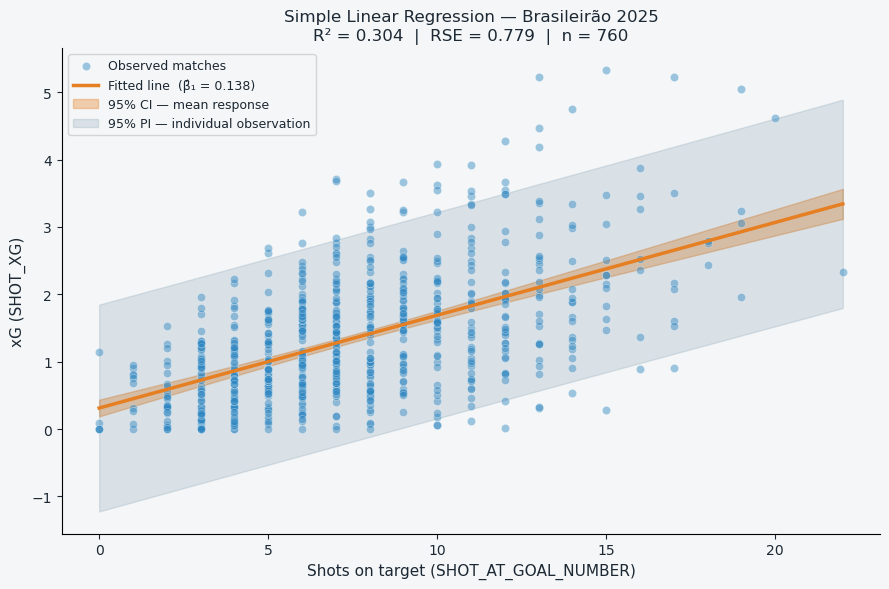

In [9]:
# ===================== SCATTER + REGRESSION LINE + CI + PI =====================

apply_style()
fig, ax = plt.subplots(figsize=(9, 6))

# Observed data
ax.scatter(
    df[PREDICTOR], df[TARGET],
    color=COLORS["secondary"], alpha=0.45, s=35,
    edgecolors="white", linewidth=0.4,
    label="Observed matches", zorder=2,
)

# Regression line
ax.plot(
    x_grid[PREDICTOR], pred_grid["mean"],
    color=COLORS["accent"], linewidth=2.5,
    label=f"Fitted line  (β̂₁ = {b1:.3f})", zorder=3,
)

# 95% Confidence Interval (mean response)
ax.fill_between(
    x_grid[PREDICTOR], pred_grid["mean_ci_lower"], pred_grid["mean_ci_upper"],
    alpha=0.35, color=COLORS["accent"],
    label="95% CI — mean response",
)

# 95% Prediction Interval (individual observation)
ax.fill_between(
    x_grid[PREDICTOR], pred_grid["obs_ci_lower"], pred_grid["obs_ci_upper"],
    alpha=0.12, color=COLORS["primary"],
    label="95% PI — individual observation",
)

ax.set_xlabel("Shots on target (SHOT_AT_GOAL_NUMBER)", fontsize=11)
ax.set_ylabel("xG (SHOT_XG)", fontsize=11)
ax.set_title(
    f"Simple Linear Regression — Brasileirão 2025\n"
    f"R² = {r2:.3f}  |  RSE = {rse:.3f}  |  n = {len(df)}",
    fontsize=12,
)
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

---
## 6 · Interpretation — Brasileirão 2025

> **Fill in after running the cells above.**

#### Variable choice
- Why `POSTSHOT_XG` over `SHOT_XG`? Post-shot xG captures actual shot placement and trajectory — it is closer to the true "danger" of the attack and correlates more strongly with goals scored.
- Why box shots over total shots? Shots from inside the box are the main driver of shot quality. Total shot count includes long-range shots that inflate volume without improving post-shot quality.

#### Inference
- **β̂₁**: each additional box shot is associated with how much extra POSTSHOT_XG? Does the magnitude match intuition for Série A?
- **p-value**: is the association statistically significant at α = 0.05?
- **R²**: what fraction of POSTSHOT_XG variance is explained by box shots alone? What other factors might explain the rest?
- **RSE**: the typical prediction error in xG units — is this acceptable for practical match analysis?

#### Prediction
- **CI vs PI**: notice the PI is always substantially wider than the CI. Even with a perfect model, individual matches carry irreducible randomness (ε) — a well-structured team can have a low-xG match and vice versa.
- Which match types might systematically fall outside the PI? (e.g., dominant possession teams that rarely lose the ball to concede counter-attacks)

#### Limitations
- Single predictor — shot volume inside the box is necessary but not sufficient. Shot placement quality, keeper positioning, and defensive pressure at the moment of the shot also matter.
- Next step: multiple linear regression (Lecture 02) — add `SHOT_CREATING_ACTIONS` and `BYPASSED_OPPONENTS_TO_PITCH_POSITION_OPPONENT_BOX` and test whether they add explanatory power beyond box shot count.